# Import Library & Files

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv")
test_df = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv")

# Exploratory Data Analysis

In [2]:
train_df.shape, test_df.shape

((116023, 52), (29006, 51))

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116023 entries, 0 to 116022
Data columns (total 52 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   trafficSource.isTrueDirect                    42890 non-null   object 
 1   purchaseValue                                 116023 non-null  float64
 2   browser                                       116023 non-null  object 
 3   device.screenResolution                       116023 non-null  object 
 4   trafficSource.adContent                       2963 non-null    object 
 5   trafficSource.keyword                         44162 non-null   object 
 6   screenSize                                    116023 non-null  object 
 7   geoCluster                                    116023 non-null  object 
 8   trafficSource.adwordsClickInfo.slot           4281 non-null    object 
 9   device.mobileDeviceBranding                   11

In [4]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29006 entries, 0 to 29005
Data columns (total 51 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   userChannel                                   29006 non-null  object 
 1   date                                          29006 non-null  int64  
 2   browser                                       29006 non-null  object 
 3   device.browserSize                            29006 non-null  object 
 4   device.browserVersion                         29006 non-null  object 
 5   deviceType                                    29006 non-null  object 
 6   device.flashVersion                           29006 non-null  object 
 7   device.isMobile                               29006 non-null  bool   
 8   device.language                               29006 non-null  object 
 9   device.mobileDeviceBranding                   29006 non-null 

In [5]:
missing_values = train_df.isna().sum()
missing_values[missing_values.sort_values(ascending=False)>0]

trafficSource.isTrueDirect                       73133
trafficSource.adContent                         113060
trafficSource.keyword                            71861
trafficSource.adwordsClickInfo.slot             111742
trafficSource.adwordsClickInfo.isVideoAd        111742
trafficSource.adwordsClickInfo.adNetworkType    111742
trafficSource.adwordsClickInfo.page             111742
pageViews                                            8
trafficSource.referralPath                       73309
totals.bounces                                   68875
new_visits                                       35505
dtype: int64

In [6]:
missing_values_test = test_df.isna().sum()
missing_values_test[missing_values_test.sort_values(ascending=False)>0]

totals.bounces                                  17274
new_visits                                       8912
pageViews                                           3
trafficSource.adContent                         28247
trafficSource.adwordsClickInfo.adNetworkType    27899
trafficSource.adwordsClickInfo.isVideoAd        27899
trafficSource.adwordsClickInfo.page             27899
trafficSource.adwordsClickInfo.slot             27899
trafficSource.isTrueDirect                      18245
trafficSource.keyword                           17962
trafficSource.referralPath                      18395
dtype: int64

## Describing Numerical columns

In [7]:
train_df.describe()

,purchaseValue,userId,gclIdPresent,sessionNumber,totals.visits,sessionId,trafficSource.adwordsClickInfo.page,pageViews,locationZone,totals.bounces,date,totalHits,sessionStart,new_visits
count,1.160230e+05,116023.000000,116023.000000,116023.000000,116023.0,1.160230e+05,4281.000000,116015.000000,116023.0,47148.0,1.160230e+05,116023.000000,1.160230e+05,80518.0
mean,2.656393e+07,61094.356231,0.037019,2.691311,1.0,1.493429e+09,1.019622,8.412352,8.0,1.0,2.016860e+07,10.607371,1.493429e+09,1.0
std,2.051825e+08,35240.756859,0.188808,10.451613,0.0,1.528798e+07,0.174517,14.344937,0.0,0.0,6.182322e+03,19.629576,1.528798e+07,0.0
min,0.000000e+00,0.000000,0.000000,1.000000,1.0,1.470035e+09,1.000000,1.000000,8.0,1.0,2.016080e+07,1.000000,1.470035e+09,1.0
25%,0.000000e+00,30603.500000,0.000000,1.000000,1.0,1.480066e+09,1.000000,1.000000,8.0,1.0,2.016112e+07,1.000000,1.480066e+09,1.0
50%,0.000000e+00,61014.000000,0.000000,1.000000,1.0,1.491646e+09,1.000000,2.000000,8.0,1.0,2.017041e+07,2.000000,1.491646e+09,1.0
75%,0.000000e+00,91616.500000,0.000000,2.000000,1.0,1.505079e+09,1.000000,10.000000,8.0,1.0,2.017091e+07,12.000000,1.505079e+09,1.0
max,2.312950e+10,122276.000000,1.000000,447.000000,1.0,1.525157e+09,5.000000,469.000000,8.0,1.0,2.018043e+07,500.000000,1.525157e+09,1.0


In [8]:
# Describing Categorical data
train_df.describe(include="object")

,trafficSource.isTrueDirect,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,device.mobileInputSelector,...,geoNetwork.city,geoNetwork.metro,device.mobileDeviceModel,trafficSource.referralPath,device.language,deviceType,userChannel,device.browserVersion,device.screenColors,geoNetwork.continent
count,42890,116023,116023,2963,44162,116023,116023,4281,116023,116023,...,116023,116023,116023,42714,116023,116023,116023,116023,116023,116023
unique,1,34,1,53,566,1,5,3,1,1,...,695,104,1,941,1,3,8,1,1,6
top,True,Chrome,not available in demo dataset,Google Merchandise Store,(not provided),medium,Region_2,Top,not available in demo dataset,not available in demo dataset,...,not available in demo dataset,not available in demo dataset,not available in demo dataset,/,not available in demo dataset,desktop,Organic Search,not available in demo dataset,not available in demo dataset,Americas
freq,42890,84508,116023,1410,39066,116023,23294,2721,116023,116023,...,60138,60138,116023,17970,116023,86480,46925,116023,116023,69856


Observation:
1. There are 14 Numerical columns and 37 Categorical columns

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Distribution of Purchase Value')

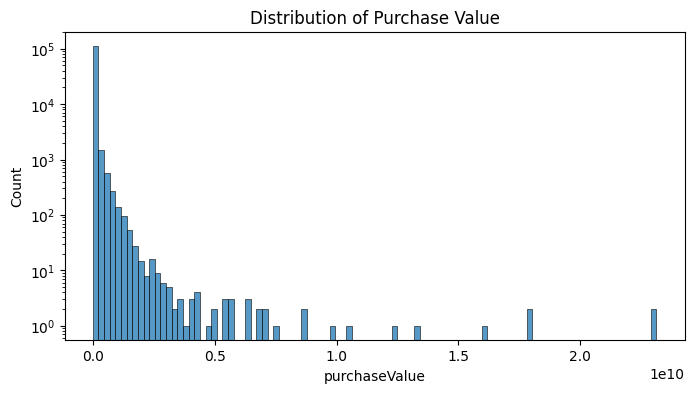

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(train_df['purchaseValue'], bins=100, log_scale=(False, True))
plt.title("Distribution of Purchase Value")

## Traffic Source Analysis

Text(0.5, 1.0, 'Traffic Medium Distribution')

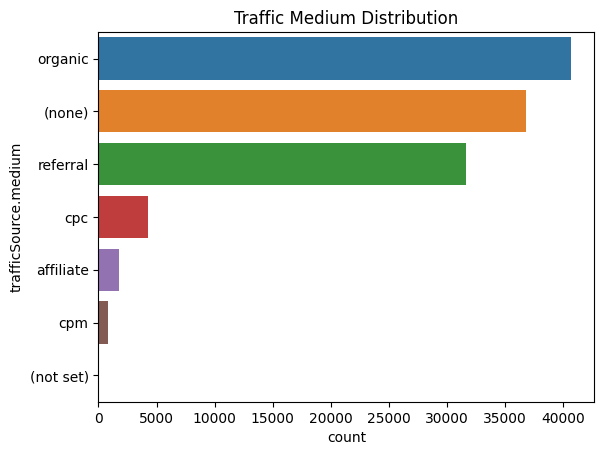

In [10]:
sns.countplot(data=train_df, y='trafficSource.medium', order=train_df['trafficSource.medium'].value_counts().index)
plt.title("Traffic Medium Distribution")

Text(0.5, 1.0, 'Top 10 Ad Contents')

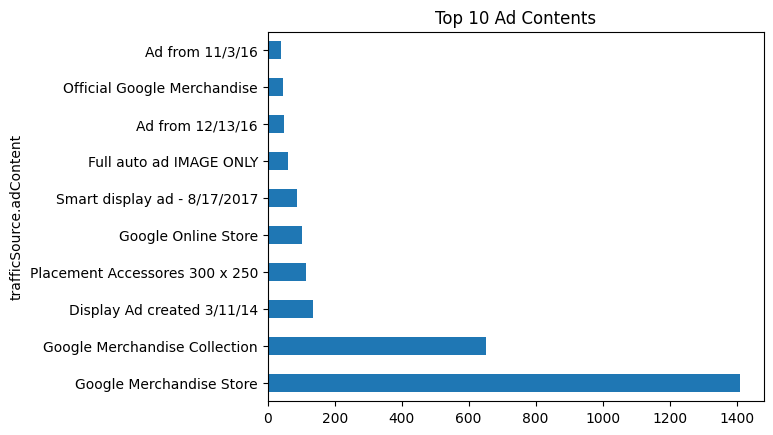

In [11]:
top_ad =train_df['trafficSource.adContent'].value_counts().head(10)
top_ad.plot(kind='barh')
plt.title("Top 10 Ad Contents")

Observation:
The count plot of trafficSource.medium reveals that Organic has higher count then (none) and then referral these three combine has around 95% dominance.

The bar chart for trafficSource.adContent shows that "Google Merchendise Store" has the moast dominace and after that "Google Merchendise Collection", which is a little less than half of the first one .

## Session Activity

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


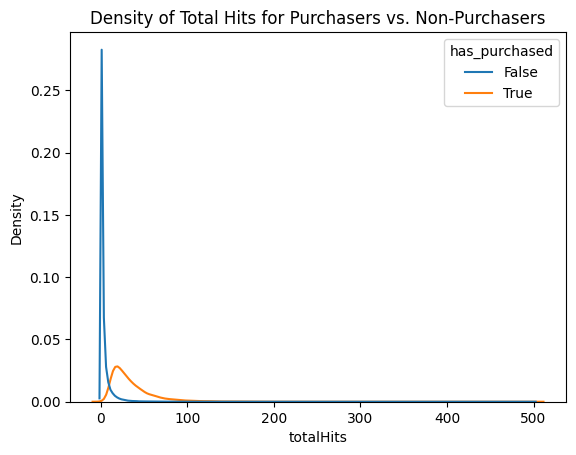

In [12]:
train_df['has_purchased'] = train_df['purchaseValue'] > 0
sns.kdeplot(data=train_df, x='totalHits', hue='has_purchased', common_norm=False)
plt.title("Density of Total Hits for Purchasers vs. Non-Purchasers")
plt.show()

Observation: Sessions that result in a purchase tend to have a significantly higher number of totalHits compared to non-purchasing sessions.

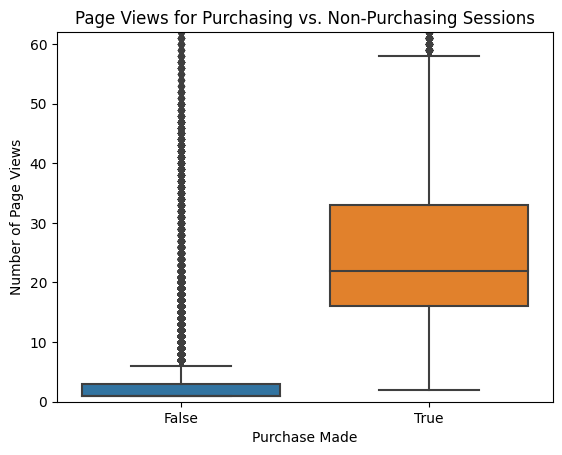

In [13]:
sns.boxplot(data=train_df, x='has_purchased', y='pageViews')
plt.title("Page Views for Purchasing vs. Non-Purchasing Sessions")
plt.xlabel("Purchase Made")
plt.ylabel("Number of Page Views")

plt.ylim(0, train_df['pageViews'].quantile(0.99))

plt.show()

In [14]:
conversion_rate = train_df['has_purchased'].mean() * 100
print("Overall Conversion Rate:", conversion_rate)

Overall Conversion Rate: 20.672625255337305


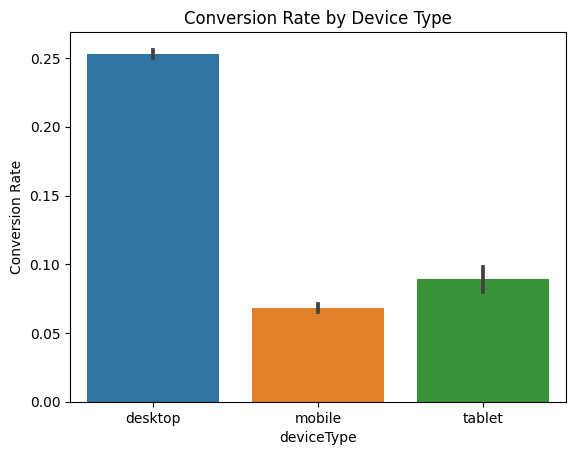

In [15]:
sns.barplot(data=train_df, x='deviceType', y='has_purchased')
plt.title("Conversion Rate by Device Type")
plt.ylabel("Conversion Rate")
plt.show()

Observation: Desktop has the highest conversion rate almost a little higher than combine of mobile and tablet.

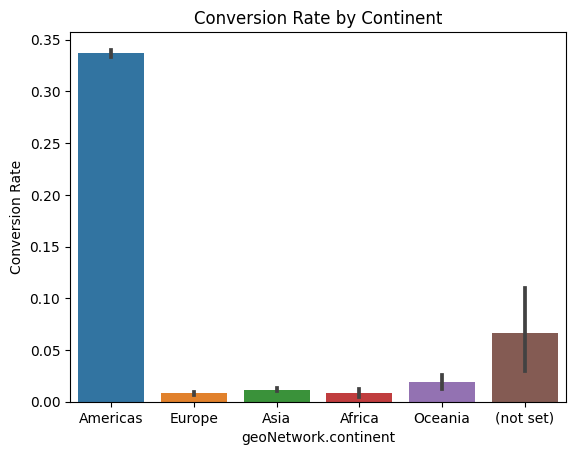

In [16]:
sns.barplot(data=train_df, x='geoNetwork.continent', y='has_purchased')
plt.title("Conversion Rate by Continent")
plt.ylabel("Conversion Rate")
plt.show()

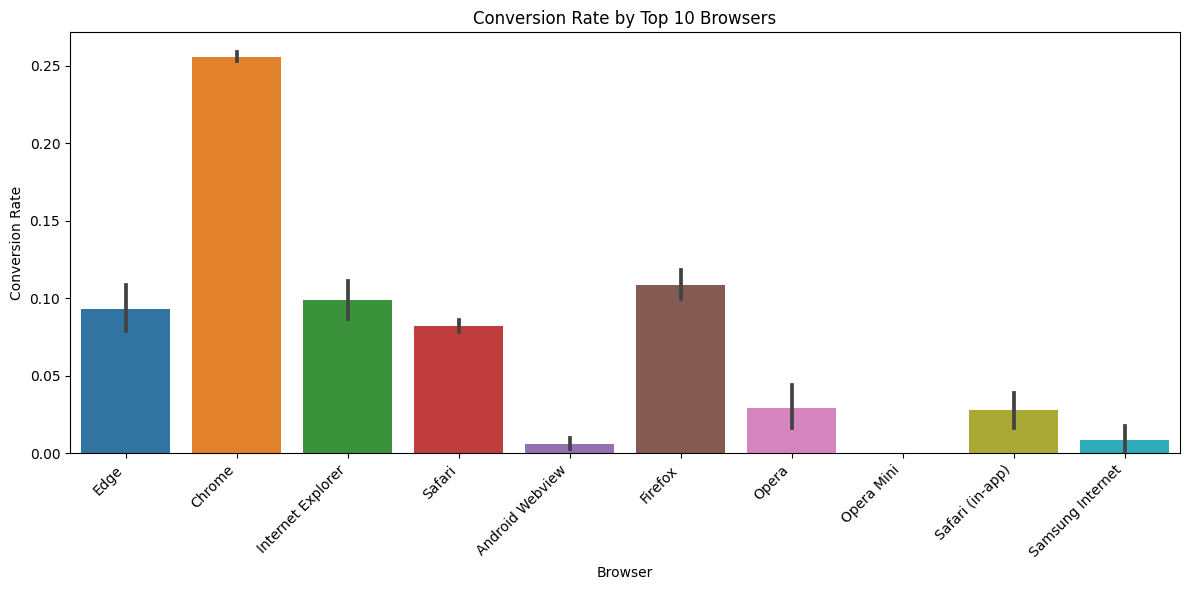

In [17]:
top_10_browsers = train_df['browser'].value_counts().head(10).index

train_df_top10 = train_df[train_df['browser'].isin(top_10_browsers)]

plt.figure(figsize=(12, 6))
sns.barplot(
    data=train_df_top10,
    x='browser',
    y='has_purchased',
)

plt.title("Conversion Rate by Top 10 Browsers")
plt.ylabel("Conversion Rate")
plt.xlabel("Browser")
plt.xticks(rotation=45, ha="right") 
plt.tight_layout()
plt.show()

## Outlier Detection

In [18]:
Q1 = train_df['purchaseValue'].quantile(0.25)
Q3 = train_df['purchaseValue'].quantile(0.75)
IQR = Q3 - Q1
outliers = train_df[(train_df['purchaseValue'] < (Q1 - 1.5 * IQR)) |
                        (train_df['purchaseValue'] > (Q3 + 1.5 * IQR))]

print(f"Total Outliers: {len(outliers)}")


Total Outliers: 23985


## Correlation Matrix

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Text(0.5, 1.0, 'Correlation Matrix')

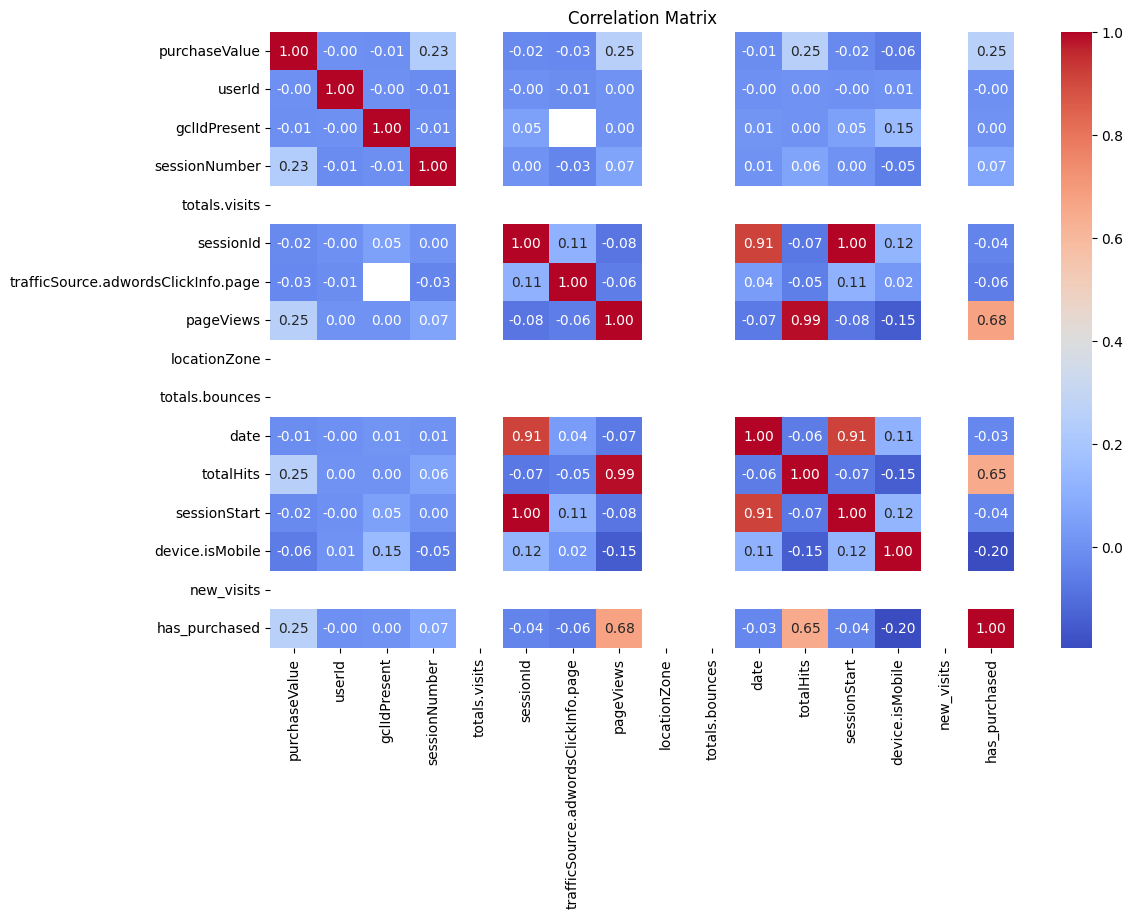

In [19]:
plt.figure(figsize=(12, 8))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")

Observation:
1. date has high correlation with both sessionId and sessionStart.
2. pageViews and totalHits has high correlation with each other.
3. sessionId and sessionStart has high correlation with each other.

# Split features and target

In [20]:
X = train_df.drop(columns=['purchaseValue'])
y = train_df['purchaseValue']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols, num_cols

(['trafficSource.isTrueDirect',
  'browser',
  'device.screenResolution',
  'trafficSource.adContent',
  'trafficSource.keyword',
  'screenSize',
  'geoCluster',
  'trafficSource.adwordsClickInfo.slot',
  'device.mobileDeviceBranding',
  'device.mobileInputSelector',
  'trafficSource.campaign',
  'device.mobileDeviceMarketingName',
  'geoNetwork.networkDomain',
  'device.operatingSystemVersion',
  'device.flashVersion',
  'geoNetwork.region',
  'trafficSource',
  'geoNetwork.networkLocation',
  'os',
  'geoNetwork.subContinent',
  'trafficSource.medium',
  'trafficSource.adwordsClickInfo.isVideoAd',
  'browserMajor',
  'locationCountry',
  'device.browserSize',
  'trafficSource.adwordsClickInfo.adNetworkType',
  'socialEngagementType',
  'geoNetwork.city',
  'geoNetwork.metro',
  'device.mobileDeviceModel',
  'trafficSource.referralPath',
  'device.language',
  'deviceType',
  'userChannel',
  'device.browserVersion',
  'device.screenColors',
  'geoNetwork.continent'],
 ['userId',
  'g

# Train-validation split

In [21]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=39
)

X_train.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,trafficSource.isTrueDirect,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,device.mobileInputSelector,...,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits,has_purchased
17382,True,Chrome,not available in demo dataset,NaN,NaN,medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,...,desktop,Referral,not available in demo dataset,26,not available in demo dataset,1502292550,Americas,False,NaN,True
814,True,Chrome,not available in demo dataset,NaN,NaN,medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,...,desktop,Direct,not available in demo dataset,10,not available in demo dataset,1490202121,Americas,False,1.0,False
18115,NaN,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_4,NaN,not available in demo dataset,not available in demo dataset,...,mobile,Organic Search,not available in demo dataset,1,not available in demo dataset,1486408495,Africa,True,1.0,False
34226,NaN,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_4,NaN,not available in demo dataset,not available in demo dataset,...,mobile,Organic Search,not available in demo dataset,1,not available in demo dataset,1487704493,Europe,True,1.0,False
95891,NaN,Chrome,not available in demo dataset,NaN,NaN,medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,...,desktop,Referral,not available in demo dataset,14,not available in demo dataset,1499316634,Americas,False,1.0,True


In [22]:
X_val.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,trafficSource.isTrueDirect,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,device.mobileInputSelector,...,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits,has_purchased
111058,True,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,not available in demo dataset,...,desktop,Direct,not available in demo dataset,5,not available in demo dataset,1488963755,Americas,False,1.0,False
30748,NaN,Chrome,not available in demo dataset,NaN,NaN,medium,Region_1,NaN,not available in demo dataset,not available in demo dataset,...,desktop,Social,not available in demo dataset,1,not available in demo dataset,1471871723,Asia,False,1.0,False
83374,NaN,Opera Mini,not available in demo dataset,NaN,NaN,medium,Region_5,NaN,not available in demo dataset,not available in demo dataset,...,mobile,Social,not available in demo dataset,1,not available in demo dataset,1512670499,Americas,True,1.0,False
102418,NaN,Chrome,not available in demo dataset,NaN,NaN,medium,Region_1,NaN,not available in demo dataset,not available in demo dataset,...,desktop,Social,not available in demo dataset,1,not available in demo dataset,1470746198,Asia,False,1.0,False
5480,True,Chrome,not available in demo dataset,NaN,NaN,medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,...,desktop,Referral,not available in demo dataset,5,not available in demo dataset,1500741342,Americas,False,NaN,False


In [23]:
y_train.head()

17382    78380000.0
814             0.0
18115           0.0
34226           0.0
95891    67710000.0
Name: purchaseValue, dtype: float64

In [24]:
y_val

111058            0.0
30748             0.0
83374             0.0
102418            0.0
5480              0.0
             ...     
112315            0.0
81906             0.0
29120             0.0
39845             0.0
11517     158400000.0
Name: purchaseValue, Length: 23205, dtype: float64

# Numerical preprocessing

In [25]:
num_imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_num = scaler.fit_transform(num_imputer.fit_transform(X_train[num_cols]))
X_val_num = scaler.transform(num_imputer.transform(X_val[num_cols]))
test_num = scaler.transform(num_imputer.transform(test_df[num_cols]))

# Label encoding for categoricals with fallback for unknowns

In [26]:
def safe_label_encode(train_df, val_df, test_df, cols):
    encoded_train, encoded_val, encoded_test = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    for col in cols:
        le = LabelEncoder()
        train_vals = train_df[col].astype(str).fillna("Unknown")
        val_vals = val_df[col].astype(str).fillna("Unknown")
        test_vals = test_df[col].astype(str).fillna("Unknown")

        le.fit(train_vals)
        known = set(le.classes_)
        val_vals = val_vals.apply(lambda x: x if x in known else "Unknown")
        test_vals = test_vals.apply(lambda x: x if x in known else "Unknown")

        if "Unknown" not in le.classes_:
            le.classes_ = np.append(le.classes_, "Unknown")

        encoded_train[col] = le.transform(train_vals)
        encoded_val[col] = le.transform(val_vals)
        encoded_test[col] = le.transform(test_vals)

    return encoded_train, encoded_val, encoded_test

X_train_cat, X_val_cat, test_cat = safe_label_encode(X_train, X_val, test_df, cat_cols)

# Combine features

In [27]:
X_train_final = np.hstack([X_train_num, X_train_cat])
X_val_final = np.hstack([X_val_num, X_val_cat])
test_final = np.hstack([test_num, test_cat])

X_train_final

array([[-0.82384153, -0.19484769,  0.03070126, ...,  0.        ,
         0.        ,  2.        ],
       [-0.93109498, -0.19484769, -0.16247431, ...,  0.        ,
         0.        ,  2.        ],
       [-0.10631278, -0.19484769, -0.16247431, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.73778695, -0.19484769, -0.16247431, ...,  0.        ,
         0.        ,  3.        ],
       [ 1.5881273 , -0.19484769, -0.16247431, ...,  0.        ,
         0.        ,  4.        ],
       [ 0.45826419, -0.19484769, -0.16247431, ...,  0.        ,
         0.        ,  2.        ]])

# RandomizedSearchCV for RandomForest

In [28]:
param_dist = {
    'n_estimators': randint(650, 850), 
    'max_depth': [35, 40, 45],         
    'min_samples_split': [2, 3],   
    'max_features': ['sqrt', 'log2'],  
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=39),
    param_distributions=param_dist,
    n_iter=25,
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1
)

#  Fit model

In [29]:
random_search.fit(X_train_final, y_train)

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=39),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [35, 40, 45],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_split': [2, 3],
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x791524d9e290>},
                   random_state=42, scoring='r2')

# Evaluate best model

In [30]:
best_model = random_search.best_estimator_
print("Train R²:", round(best_model.score(X_train_final, y_train), 3))
print("Val R²:", round(best_model.score(X_val_final, y_val), 3))
print("Best Parameters:", random_search.best_params_)


Train R²: 1.0
Val R²: 0.627
Best Parameters: {'bootstrap': False, 'max_depth': 35, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 731}


# Predict on test data and save

In [31]:
preds = best_model.predict(test_final)
submission = pd.DataFrame({
    'id': test_df.index,
    'purchaseValue': preds
})
submission.to_csv("submission.csv", index=False)
print("submission.csv saved!")


submission.csv saved!
